In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier
import joblib

In [3]:
from google.colab import files

uploaded = files.upload()

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv


In [4]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")

In [5]:
print(df.shape)
df.head()

(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
print(df["Shipping Mode"].head())
print(df["Market"].head())
print(df["Customer Segment"].head())

0    Standard Class
1    Standard Class
2    Standard Class
3    Standard Class
4    Standard Class
Name: Shipping Mode, dtype: object
0    Pacific Asia
1    Pacific Asia
2    Pacific Asia
3    Pacific Asia
4    Pacific Asia
Name: Market, dtype: object
0       Consumer
1       Consumer
2       Consumer
3    Home Office
4      Corporate
Name: Customer Segment, dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [8]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [9]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

In [13]:
df.dtypes

,0
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object


In [14]:
df.to_csv("cleaned_supply_chain.csv", index=False)

print("cleaned_supply_chain.csv saved successfully!")

cleaned_supply_chain.csv saved successfully!


In [15]:
from google.colab import files

files.download("cleaned_supply_chain.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Delay in delivery
df["Delay_Days"] = (
    df["Days for shipping (real)"] -
    df["Days for shipment (scheduled)"]
)

# Shipping Efficiency
df["Shipping_Efficiency"] = (
    df["Days for shipment (scheduled)"] /
    df["Days for shipping (real)"]
)

# Order Date Features
df["Order_Month"] = df["order date (DateOrders)"].dt.month
df["Order_Day"] = df["order date (DateOrders)"].dt.day
df["Order_Weekday"] = df["order date (DateOrders)"].dt.day_name()

In [17]:
df[[
    "Delay_Days",
    "Shipping_Efficiency",
    "Order_Month",
    "Order_Day",
    "Order_Weekday"
]].head()

,Delay_Days,Shipping_Efficiency,Order_Month,Order_Day,Order_Weekday
0,-1,1.333333,1,31,Wednesday
1,1,0.800000,1,13,Saturday
2,0,1.000000,1,13,Saturday
3,-1,1.333333,1,13,Saturday
4,-2,2.000000,1,13,Saturday


In [18]:
df.to_csv("feature_engineered_supply_chain.csv", index=False)

print("feature_engineered_supply_chain.csv saved successfully!")

feature_engineered_supply_chain.csv saved successfully!


In [20]:
from google.colab import files

files.download("feature_engineered_supply_chain.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
features = [
    "Shipping Mode",
    "Market",
    "Order Region",
    "Category Name",
    "Customer Segment",
    "Order Item Quantity",
    "Sales",
    "Delay_Days",
    "Shipping_Efficiency",
    "Order_Month",
    "Order_Day",
    "Order_Weekday"
]

X = df[features]
y = df["Late_delivery_risk"]

In [22]:
print(X.head())
print("\nTarget Variable:")
print(y.head())

    Shipping Mode        Market    Order Region   Category Name  \
0  Standard Class  Pacific Asia  Southeast Asia  Sporting Goods   
1  Standard Class  Pacific Asia      South Asia  Sporting Goods   
2  Standard Class  Pacific Asia      South Asia  Sporting Goods   
3  Standard Class  Pacific Asia         Oceania  Sporting Goods   
4  Standard Class  Pacific Asia         Oceania  Sporting Goods   

  Customer Segment  Order Item Quantity   Sales  Delay_Days  \
0         Consumer                    1  327.75          -1   
1         Consumer                    1  327.75           1   
2         Consumer                    1  327.75           0   
3      Home Office                    1  327.75          -1   
4        Corporate                    1  327.75          -2   

   Shipping_Efficiency  Order_Month  Order_Day Order_Weekday  
0             1.333333            1         31     Wednesday  
1             0.800000            1         13      Saturday  
2             1.000000       

In [23]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Shipping Mode",
    "Market",
    "Order Region",
    "Category Name",
    "Customer Segment",
    "Order_Weekday"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

/tmp/ipykernel_1279/1402004532.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_1279/1402004532.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipykernel_1279/1402004532.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

In [24]:
print(X.head())

   Shipping Mode  Market  Order Region  Category Name  Customer Segment  \
0              3       3            15             40                 0   
1              3       3            13             40                 0   
2              3       3            13             40                 0   
3              3       3            11             40                 2   
4              3       3            11             40                 1   

   Order Item Quantity   Sales  Delay_Days  Shipping_Efficiency  Order_Month  \
0                    1  327.75          -1             1.333333            1   
1                    1  327.75           1             0.800000            1   
2                    1  327.75           0             1.000000            1   
3                    1  327.75          -1             1.333333            1   
4                    1  327.75          -2             2.000000            1   

   Order_Day  Order_Weekday  
0         31              6  
1       

In [25]:
print(encoders["Shipping Mode"].classes_)

['First Class' 'Same Day' 'Second Class' 'Standard Class']


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [27]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (144415, 12)
Testing Features : (36104, 12)
Training Labels  : (144415,)
Testing Labels   : (36104,)


In [28]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [30]:
model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [31]:
y_pred = model.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [32]:
print(y_pred[:10])

[0 0 0 0 1 0 1 0 1 1]


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance ")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Performance 
Accuracy : 0.9745
Precision: 0.9556
Recall   : 1.0000
F1-Score : 0.9773


In [37]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15388   920]
 [    0 19796]]


In [38]:
print("Classification Report")
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     16308
           1       0.96      1.00      0.98     19796

    accuracy                           0.97     36104
   macro avg       0.98      0.97      0.97     36104
weighted avg       0.98      0.97      0.97     36104



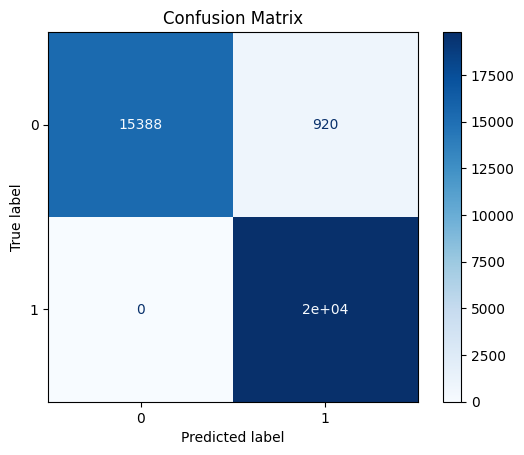

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [47]:
import joblib

# Save model
model.save_model("xgboost_model.json")

# Save encoders
joblib.dump(encoders, "label_encoders.pkl")

print("Model and Label Encoders saved successfully!")

Model and Label Encoders saved successfully!


In [42]:
from google.colab import files

files.download("xgboost_model.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
from google.colab import files
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>